In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive mounted!")

Mounted at /content/drive
✓ Google Drive mounted!


# Heart Data Cleaning & Logistic Regression

## Introduction
This project performs data cleaning, preprocessing, and applies Logistic Regression on a heart dataset to predict outcomes based on medical features.

In [ ]:
# # Core libraries
import pandas as pd
import numpy as np

# # Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# # ML tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# # Load heart dataset
heart_data = pd.read_csv("/content/drive/MyDrive/ML/Heart/heart-2.csv")

## Initial Inspection
We check dataset shape, data types, and summary statistics.

In [ ]:
# # View first rows
print(heart_data.head())

# # Dataset structure
print(heart_data.info())

# # Statistical summary
print(heart_data.describe())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 

## Duplicates Check
We check for duplicate rows in the dataset.

In [ ]:
# # Check duplicates
print("Duplicates:", heart_data.duplicated().sum())

# # Remove duplicates
heart_data = heart_data.drop_duplicates()

Duplicates: 0


## Missing Values
We check missing values and decide whether to fill or remove them.

In [ ]:
# # Check missing values per column
print(heart_data.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
# # Select numeric columns
numeric_cols = heart_data.select_dtypes(include=np.number).columns
print(numeric_cols)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [ ]:
# # Outlier treatment using IQR
for col in numeric_cols:
    if col != "target":
        Q1 = heart_data[col].quantile(0.25)
        Q3 = heart_data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        heart_data[col] = np.where(heart_data[col] < lower, lower, heart_data[col])
        heart_data[col] = np.where(heart_data[col] > upper, upper, heart_data[col])

##Correlation & their p-values

/tmp/ipykernel_803/3817906012.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  _, p = pearsonr(heart_data[col1], heart_data[col2])


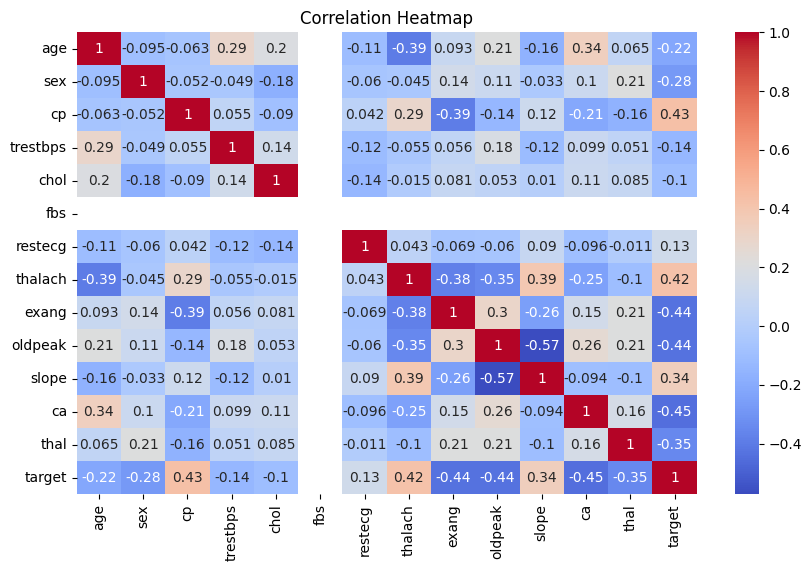

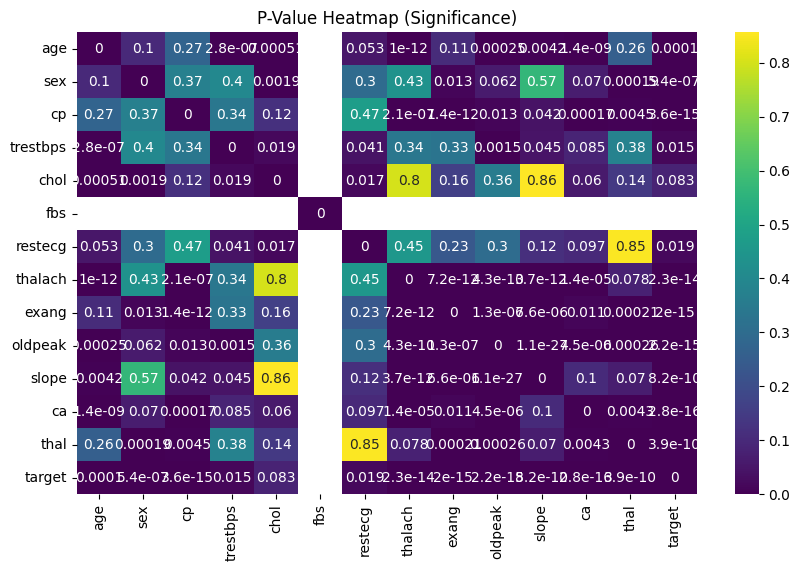

,Correlation,P-Value
target,1.000000,0.000000e+00
cp,0.432080,3.627384e-15
thalach,0.420408,2.307962e-14
slope,0.343940,8.221389e-10
restecg,0.134874,1.903361e-02
chol,-0.099932,8.295977e-02
trestbps,-0.140083,1.483820e-02
age,-0.221476,1.039484e-04
sex,-0.283609,5.402436e-07
thal,-0.350021,3.936646e-10


In [ ]:
# Correlation
## STEP 1: Import Required Library
from scipy.stats import pearsonr

# STEP 2: Correlation Matrix (Numerical)
corr_matrix = heart_data.corr()
corr_matrix

# STEP 3: P-Value Matrix Calculation
# # Create empty dataframe for p-values
p_values = pd.DataFrame(np.ones_like(corr_matrix), columns=corr_matrix.columns, index=corr_matrix.index)

# # Calculate p-values for each feature pair
for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 == col2:
            p_values.loc[col1, col2] = 0
        else:
            _, p = pearsonr(heart_data[col1], heart_data[col2])
            p_values.loc[col1, col2] = p

p_values

# STEP 4: Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

# STEP 5: P-Value Heatmap (Significance Map)
plt.figure(figsize=(10,6))
sns.heatmap(p_values, cmap="viridis", annot=True)
plt.title("P-Value Heatmap (Significance)")
plt.show()

#STEP 6: Significant Correlations with Target
# # Extract correlation with target
target_corr = corr_matrix["target"].sort_values(ascending=False)

# # Extract p-values with target
target_pvals = p_values["target"]

result = pd.DataFrame({
    "Correlation": target_corr,
    "P-Value": target_pvals
})

result.sort_values(by="Correlation", ascending=False)

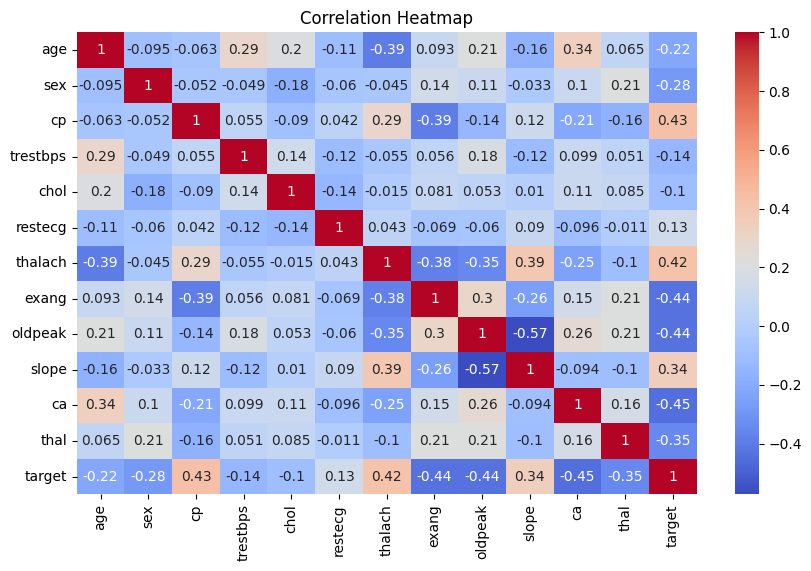

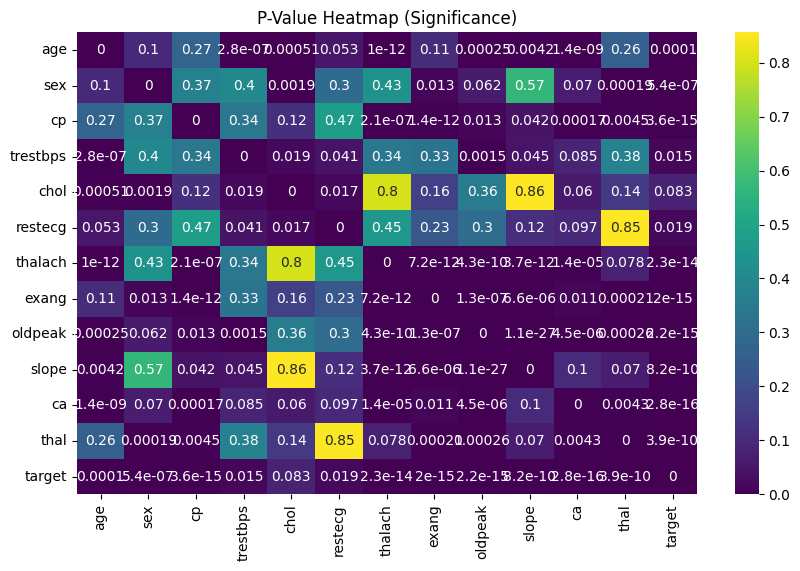

,Correlation,P-Value
target,1.000000,0.000000e+00
cp,0.432080,3.627384e-15
thalach,0.420408,2.307962e-14
slope,0.343940,8.221389e-10
restecg,0.134874,1.903361e-02
chol,-0.099932,8.295977e-02
trestbps,-0.140083,1.483820e-02
age,-0.221476,1.039484e-04
sex,-0.283609,5.402436e-07
thal,-0.350021,3.936646e-10


In [ ]:
# Correlation without fbs variable
# STEP 1: Import Required Library
from scipy.stats import pearsonr

# STEP 2: Correlation Matrix (Numerical) — fbs removed
corr_matrix = heart_data.drop(columns=["fbs"]).corr()
corr_matrix

# STEP 3: P-Value Matrix Calculation
# Create empty dataframe for p-values
p_values = pd.DataFrame(
    np.ones_like(corr_matrix),
    columns=corr_matrix.columns,
    index=corr_matrix.index
)

# Calculate p-values for each feature pair
for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 == col2:
            p_values.loc[col1, col2] = 0
        else:
            _, p = pearsonr(
                heart_data.drop(columns=["fbs"])[col1],
                heart_data.drop(columns=["fbs"])[col2]
            )
            p_values.loc[col1, col2] = p

p_values

# STEP 4: Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

# STEP 5: P-Value Heatmap (Significance Map)
plt.figure(figsize=(10,6))
sns.heatmap(p_values, cmap="viridis", annot=True)
plt.title("P-Value Heatmap (Significance)")
plt.show()

# STEP 6: Significant Correlations with Target
# Extract correlation with target
target_corr = corr_matrix["target"].sort_values(ascending=False)

# Extract p-values with target
target_pvals = p_values["target"]

result = pd.DataFrame({
    "Correlation": target_corr,
    "P-Value": target_pvals
})

result.sort_values(by="Correlation", ascending=False)

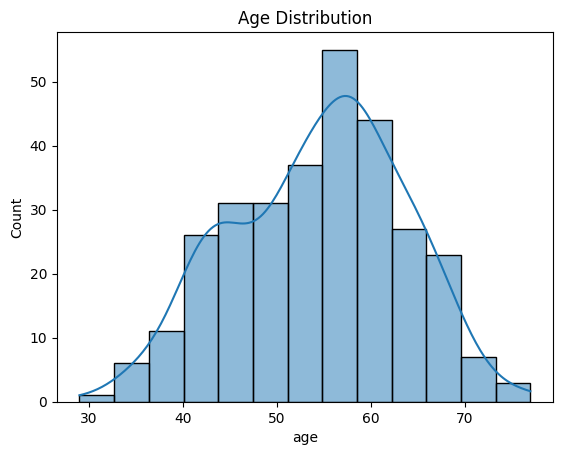

In [ ]:
# # Age distribution visualization
sns.histplot(heart_data["age"], kde=True)
plt.title("Age Distribution")
plt.show()

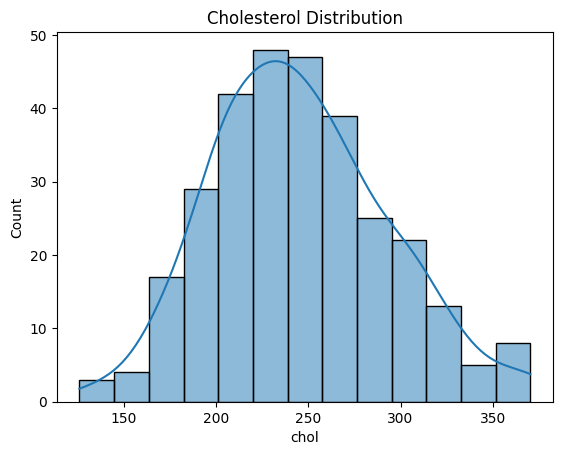

In [ ]:
# # Cholesterol distribution
sns.histplot(heart_data["chol"], kde=True)
plt.title("Cholesterol Distribution")
plt.show()

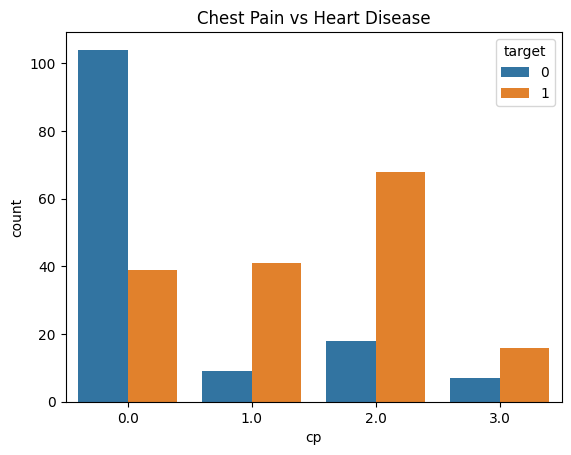

In [ ]:
# # Relationship between chest pain and disease
sns.countplot(x="cp", hue="target", data=heart_data)
plt.title("Chest Pain vs Heart Disease")
plt.show()

In [ ]:
# # Split features and target
X = heart_data.drop("target", axis=1)
y = heart_data["target"]

# # Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# # Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# # Convert back to DataFrame
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

# # Final shapes check
print(X_train.shape, X_test.shape)

(241, 13) (61, 13)


target
1    164
0    138
Name: count, dtype: int64


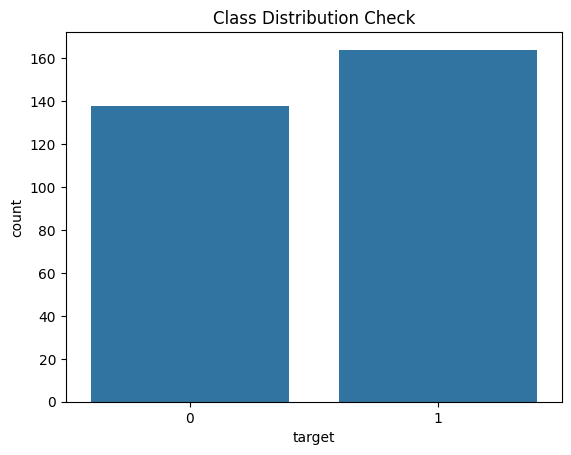

In [ ]:
# # Check target balance
print(heart_data["target"].value_counts())

sns.countplot(x="target", data=heart_data)
plt.title("Class Distribution Check")
plt.show()

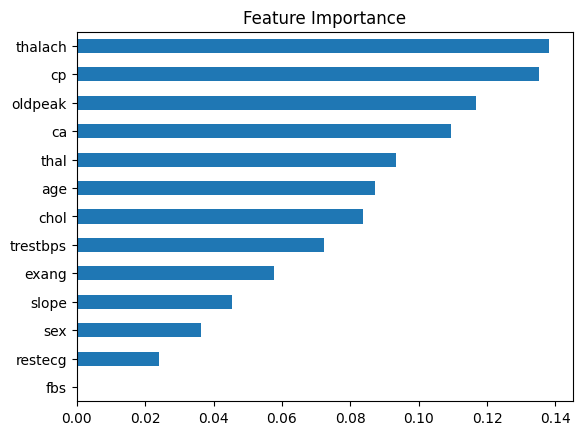

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# # Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

In [ ]:
# # Correlation with target only
print(heart_data.corr()["target"].sort_values(ascending=False))

target      1.000000
cp          0.432080
thalach     0.420408
slope       0.343940
restecg     0.134874
chol       -0.099932
trestbps   -0.140083
age        -0.221476
sex        -0.283609
thal       -0.350021
oldpeak    -0.435099
exang      -0.435601
ca         -0.447434
fbs              NaN
Name: target, dtype: float64


In [ ]:
# # Save cleaned dataset
heart_data.to_csv("heart_data_cleaned.csv", index=False)

## Logistic Regression Model
We train a logistic regression model for classification.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8032786885245902
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        28
           1       0.82      0.82      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



##Confusion Matrix

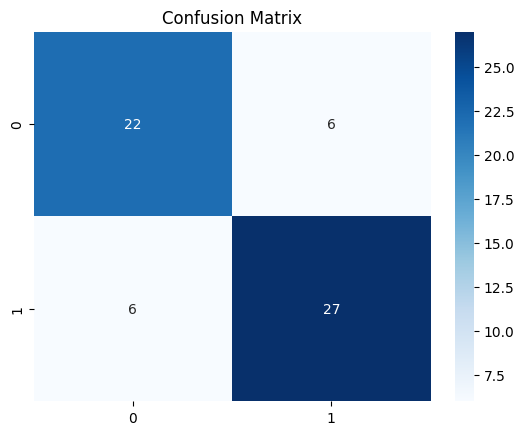

In [ ]:
from sklearn.metrics import confusion_matrix

#Confusion Matrix (Visualization)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

##ROC Curve

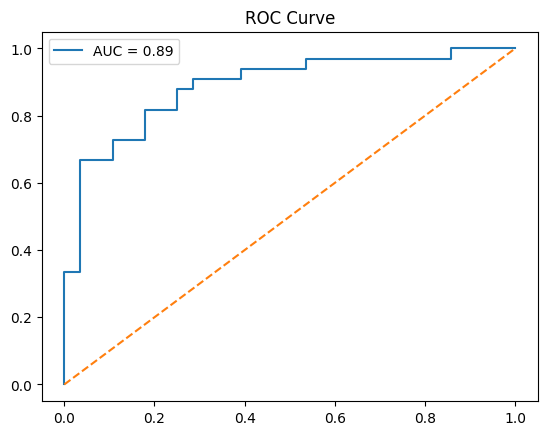

In [ ]:
from sklearn.metrics import roc_curve, auc

#ROC Curve (Model Evaluation)
y_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()